### Instalando e Carregando Stopwords em Português com NLTK

In [ ]:
# Instale o NLTK se ainda não tiver feito
# !pip install nltk

import nltk

# Baixe o corpus de stopwords. Você só precisa fazer isso uma vez.
# Se já baixou, pode comentar esta linha.
nltk.download('stopwords')

from nltk.corpus import stopwords

# Carregue as stopwords em português
portuguese_stopwords = stopwords.words('portuguese')

print(f"Número de stopwords em português: {len(portuguese_stopwords)}")
print("Primeiras 10 stopwords:", portuguese_stopwords[:10])

Número de stopwords em português: 207
Primeiras 10 stopwords: ['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import io
import requests

# 1. Carregamento e Limpeza de Dados

In [ ]:
def clean_currency(value):
    if isinstance(value, str):
        return float(value.replace('.', '').replace(',', '.'))
    return float(value)

In [ ]:
from typing_extensions import DefaultDict
# Lendo o arquivo

# Isso abrirá uma janela pedindo permissão para acessar seu Drive
#drive.mount('/content/drive')

# O caminho sempre começará com '/content/drive/My Drive/'
# Substitua pelo caminho da sua pasta e nome do arquivo
#caminho_drive = '/content/drive/My Drive/dados_pbh/dados_abertos_despesas_a_partir_2021.csv'

# Leitura do arquivo
#df = pd.read_csv(caminho_drive, sep=';', encoding='utf8')

#print("Arquivo carregado com sucesso!")


# 1. Conversão do link de compartilhamento para link de download direto
# O ID do  arquivo é: 1DLeXqCQC9IxcziwNBvdkEcHPqHjNijrm
file_id = '1DLeXqCQC9IxcziwNBvdkEcHPqHjNijrm'
url = f'https://drive.google.com/uc?export=download&id={file_id}&confirm=t'



In [ ]:
# Instale gdown para lidar com downloads do Google Drive, especialmente para arquivos grandes
!pip install gdown

In [ ]:
import gdown

# O ID do arquivo do Google Drive
file_id = '1DLeXqCQC9IxcziwNBvdkEcHPqHjNijrm'

# Caminho para salvar o arquivo temporariamente no ambiente Colab
output_file = 'dados_abertos_despesas.csv'

# Baixa o arquivo do Google Drive usando gdown
gdown.download(id=file_id, output=output_file, quiet=False, fuzzy=True)

print(f"Arquivo '{output_file}' baixado com sucesso!")

Downloading...
From (original): https://drive.google.com/uc?id=1DLeXqCQC9IxcziwNBvdkEcHPqHjNijrm
From (redirected): https://drive.google.com/uc?id=1DLeXqCQC9IxcziwNBvdkEcHPqHjNijrm&confirm=t&uuid=34bdf0b4-c216-4dfe-bfc9-8419bc1a31d9
To: /content/dados_abertos_despesas.csv
100%|██████████| 683M/683M [00:12<00:00, 56.4MB/s]

Arquivo 'dados_abertos_despesas.csv' baixado com sucesso!


In [ ]:
# Lendo o conteúdo como CSV (usando o separador ';' identificado no arquivo)
df = pd.read_csv(output_file, sep=';', encoding='utf8')

print("DataFrame carregado com sucesso!")

/tmp/ipykernel_7823/2688156847.py:2: DtypeWarning: Columns (52,54,56,58,60,62) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(output_file, sep=';', encoding='utf8')


DataFrame carregado com sucesso!


In [ ]:
df.head()

,EXERCICIO,ANO_EMPENHO,UO_EMPENHO,NUMERO_EMPENHO,DATA_EMPENHO,VALOR_EMPENHO,VALOR_EMPENHO_ANULADO,INSTRUMENTO_JURIDICO,ANO_LICITACAO,MODALIDADE_LICITACAO,...,CODIGO_FONTE,DESCRICAO_CODIGO_FONTE,DETALHAMENTO_FONTE,DESCRICAO_DETALHAMENTO_FONTE,CODIGO_ORCAMENTARIO,DESCRICAO_CODIGO_ORCAMENTARIO,FONTE,NOME_FONTE,FONTE_SINTETICA,NOME_FONTE_SINTETICA
0,2021,2019,4001,4405,12/13/2019 00:00:00,"230000,00","0,00",1.201808e+16,2018.0,9,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,OUTRAS DESPESAS CORRENTES,0.0,RECURSOS ORDINÁRIOS DO TESOURO
1,2021,2020,1018,85,10/30/2020 00:00:00,"492182,37","0,00",1.202010e+16,NaN,8,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,OUTRAS DESPESAS CORRENTES,30.0,CAPTAÇÃO DE RECURSOS VINCULADOS
2,2021,2020,1018,84,10/27/2020 00:00:00,"563056,48","0,00",1.202010e+16,NaN,8,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,OUTRAS DESPESAS CORRENTES,30.0,CAPTAÇÃO DE RECURSOS VINCULADOS
3,2021,2020,1018,115,12/30/2020 00:00:00,"302631,56","0,00",1.202010e+16,NaN,8,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,OUTRAS DESPESAS CORRENTES,30.0,CAPTAÇÃO DE RECURSOS VINCULADOS
4,2021,2020,2100,743,09/30/2020 00:00:00,"37000,00","0,00",1.201908e+16,2019.0,6,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,OUTRAS DESPESAS CORRENTES,0.0,RECURSOS ORDINÁRIOS DO TESOURO


In [ ]:
# 2. Carregamento dos dados via requisição HTTP
response = requests.get(url)
content = response.content

In [ ]:
# Lendo o conteúdo como CSV (usando o separador ';' identificado no arquivo)
df = pd.read_csv(io.StringIO(content.decode('utf8')), sep=';')

In [ ]:
df.head()

,EXERCICIO,ANO_EMPENHO,UO_EMPENHO,NUMERO_EMPENHO,DATA_EMPENHO,VALOR_EMPENHO,VALOR_EMPENHO_ANULADO,INSTRUMENTO_JURIDICO,ANO_LICITACAO,MODALIDADE_LICITACAO,...,DETALHAMENTO_FONTE,DESCRICAO_DETALHAMENTO_FONTE,CODIGO_ORCAMENTARIO,DESCRICAO_CODIGO_ORCAMENTARIO,FONTE,NOME_FONTE,FONTE_SINTETICA,NOME_FONTE_SINTETICA,MEDIA_CATEGORIA,DESVIO_RELATIVO
0,2021,2019,4001,4405,12/13/2019 00:00:00,230000.00,"0,00",1.201808e+16,2018.0,9,...,NaN,NaN,NaN,NaN,3.0,OUTRAS DESPESAS CORRENTES,0.0,RECURSOS ORDINÁRIOS DO TESOURO,1.068411e+06,0.215273
1,2021,2020,1018,85,10/30/2020 00:00:00,492182.37,"0,00",1.202010e+16,NaN,8,...,NaN,NaN,NaN,NaN,3.0,OUTRAS DESPESAS CORRENTES,30.0,CAPTAÇÃO DE RECURSOS VINCULADOS,1.068411e+06,0.460667
2,2021,2020,1018,84,10/27/2020 00:00:00,563056.48,"0,00",1.202010e+16,NaN,8,...,NaN,NaN,NaN,NaN,3.0,OUTRAS DESPESAS CORRENTES,30.0,CAPTAÇÃO DE RECURSOS VINCULADOS,1.068411e+06,0.527003
3,2021,2020,1018,115,12/30/2020 00:00:00,302631.56,"0,00",1.202010e+16,NaN,8,...,NaN,NaN,NaN,NaN,3.0,OUTRAS DESPESAS CORRENTES,30.0,CAPTAÇÃO DE RECURSOS VINCULADOS,1.068411e+06,0.283254
4,2021,2020,2100,743,09/30/2020 00:00:00,37000.00,"0,00",1.201908e+16,2019.0,6,...,NaN,NaN,NaN,NaN,3.0,OUTRAS DESPESAS CORRENTES,0.0,RECURSOS ORDINÁRIOS DO TESOURO,1.606763e+05,0.230275


Análise descritiva do dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737544 entries, 0 to 737543
Data columns (total 63 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   EXERCICIO                      737544 non-null  int64  
 1   ANO_EMPENHO                    737544 non-null  int64  
 2   UO_EMPENHO                     737544 non-null  int64  
 3   NUMERO_EMPENHO                 737544 non-null  int64  
 4   DATA_EMPENHO                   736838 non-null  object 
 5   VALOR_EMPENHO                  737544 non-null  object 
 6   VALOR_EMPENHO_ANULADO          737544 non-null  object 
 7   INSTRUMENTO_JURIDICO           275060 non-null  float64
 8   ANO_LICITACAO                  266152 non-null  float64
 9   MODALIDADE_LICITACAO           737544 non-null  int64  
 10  NUMERO_LICITACAO               266152 non-null  float64
 11  CLASSIFICACAO                  737544 non-null  object 
 12  JUSTIFICATIVA_SUCINTA         

In [ ]:
df.describe()

,EXERCICIO,ANO_EMPENHO,UO_EMPENHO,NUMERO_EMPENHO,INSTRUMENTO_JURIDICO,ANO_LICITACAO,MODALIDADE_LICITACAO,NUMERO_LICITACAO,ANO_LIQUIDACAO,UO_LIQUIDACAO,...,GRUPO_DESPESA,MODALIDADE_APLICACAO,ELEMENTO_DESPESA,ITEM_DESPESA,GRUPO_FONTE,CODIGO_FONTE,DETALHAMENTO_FONTE,CODIGO_ORCAMENTARIO,FONTE,FONTE_SINTETICA
count,737544.000000,737544.000000,737544.000000,737544.000000,2.750600e+05,266152.000000,737544.000000,2.661520e+05,694901.000000,694901.000000,...,737544.000000,737544.000000,737544.000000,737544.000000,442201.000000,442201.000000,442201.000000,442201.000000,295343.000000,295343.000000
mean,2023.022438,2022.920593,2219.492699,4573.972848,1.202009e+16,2020.062438,7.855323,7.444855e+05,2023.004073,2213.754097,...,2.620874,89.786729,37.747325,17.784169,1.047128,544.124138,31.977479,246.516982,0.118090,9.479717
std,1.459633,1.472291,909.298771,17730.639637,2.770160e+12,2.479757,1.326713,8.917489e+07,1.446653,912.731433,...,0.937178,3.142734,21.157102,24.315813,0.211913,75.988053,152.973098,798.343359,0.616151,20.140476
min,2021.000000,2016.000000,101.000000,1.000000,1.200711e+16,2007.000000,1.000000,1.000000e+00,2021.000000,101.000000,...,1.000000,20.000000,1.000000,1.000000,1.000000,500.000000,0.000000,0.000000,0.000000,0.000000
25%,2022.000000,2022.000000,2200.000000,477.000000,1.201808e+16,2019.000000,8.000000,1.200000e+01,2022.000000,2200.000000,...,3.000000,90.000000,30.000000,2.000000,1.000000,500.000000,0.000000,0.000000,0.000000,0.000000
50%,2023.000000,2023.000000,2302.000000,1557.000000,1.202106e+16,2021.000000,8.000000,3.000000e+01,2023.000000,2302.000000,...,3.000000,90.000000,39.000000,6.000000,1.000000,500.000000,0.000000,0.000000,0.000000,0.000000
75%,2024.000000,2024.000000,2702.000000,5399.000000,1.202223e+16,2022.000000,8.000000,6.300000e+01,2024.000000,2702.000000,...,3.000000,90.000000,40.000000,23.000000,1.000000,600.000000,0.000000,0.000000,0.000000,5.000000
max,2026.000000,2026.000000,4002.000000,567578.000000,1.202433e+16,2024.000000,32.000000,4.001277e+10,2026.000000,4002.000000,...,6.000000,91.000000,98.000000,99.000000,2.000000,802.000000,791.000000,9999.000000,9.000000,80.000000


# Convertendo colunas de valor para float

In [ ]:
df['VALOR_EMPENHO'] = df['VALOR_EMPENHO'].apply(clean_currency)
df['VALOR_LIQUIDACAO'] = df['VALOR_LIQUIDACAO'].apply(clean_currency)
df['VALOR_ORDEM_PAGAMENTO'] = df['VALOR_ORDEM_PAGAMENTO'].apply(clean_currency)


# 2. Engenharia de Variáveis (Feature Engineering)

In [ ]:
# Criamos uma métrica de desvio relativo por categoria (Elemento de Despesa)
# Isso ajuda a identificar o que está "fora da curva" dentro do seu próprio grupo
df['MEDIA_CATEGORIA'] = df.groupby('NOME_ELEMENTO_DESPESA')['VALOR_EMPENHO'].transform('mean')
df['DESVIO_RELATIVO'] = df['VALOR_EMPENHO'] / (df['MEDIA_CATEGORIA'] + 1) # +1 para evitar divisão por zero

# 3. Preparação do Pipeline de Machine Learning

In [ ]:
# Vamos processar texto (Justificativa) e números (Valores e Desvios) simultaneamente
numeric_features = ['VALOR_EMPENHO', 'VALOR_ORDEM_PAGAMENTO', 'DESVIO_RELATIVO']
text_feature = 'JUSTIFICATIVA_SUCINTA'

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('text', TfidfVectorizer(max_features=100, stop_words=portuguese_stopwords), text_feature)
    ])

# 4. Implementação do Modelo (Isolation Forest)

In [ ]:
# O Isolation Forest é ideal para anomalias pois "isola" observações raras em árvores de decisão
model = IsolationForest(contamination=0.05, random_state=42) # 5% de margem para suspeitos

In [ ]:
# Executando o processamento
X = preprocessor.fit_transform(df)
df['ANOMALY_SCORE'] = model.fit_predict(X)

In [ ]:
# No Isolation Forest: -1 indica anomalia, 1 indica normalidade
df['STATUS_AUDITORIA'] = df['ANOMALY_SCORE'].map({1: 'Normal', -1: 'SUSPEITO'})

# 5. Resultados e Prescrição

In [ ]:
anomalias = df[df['STATUS_AUDITORIA'] == 'SUSPEITO'][
    ['UO', 'NOME_UO', 'NOME_CREDOR', 'NUMERO_EMPENHO','VALOR_EMPENHO','DATA_EMPENHO', 'NOME_ELEMENTO_DESPESA', 'JUSTIFICATIVA_SUCINTA','NUMERO_ORDEM_PAGAMENTO','VALOR_ORDEM_PAGAMENTO', 'DATA_ORDEM_PAGAMENTO','STATUS_AUDITORIA']
]

In [ ]:
print(f"Total de registros analisados: {len(df)}")
print(f"Casos sinalizados para auditoria manual: {len(anomalias)}")
print("\n--- Exemplos de Casos Suspeitos (com UO e Nome da UO) ---")
print(anomalias.head())

Total de registros analisados: 737544
Casos sinalizados para auditoria manual: 36860

--- Exemplos de Casos Suspeitos (com UO e Nome da UO) ---
         UO                                       NOME_UO  \
7666   2505  FUNDAÇÃO DE PARQUES MUNICIPAIS E ZOOBOTÂNICA   
19609  1011         FUNDO MUNICIPAL DE ASSISTÊNCIA SOCIAL   
19610  1011         FUNDO MUNICIPAL DE ASSISTÊNCIA SOCIAL   
19611  1011         FUNDO MUNICIPAL DE ASSISTÊNCIA SOCIAL   
19612  1011         FUNDO MUNICIPAL DE ASSISTÊNCIA SOCIAL   

                        NOME_CREDOR  NUMERO_EMPENHO  VALOR_EMPENHO  \
7666   CONSTRUTORA TECNIRAMA EIRELI            1417       223925.0   
19609                           NaN             894          300.0   
19610                           NaN             895          300.0   
19611                           NaN             896          300.0   
19612                           NaN            3734          300.0   

              DATA_EMPENHO                          NOME_ELEMENTO_DE


# Exportando para facilitar a auditoria

In [ ]:
import pandas as pd

# Create a temporary DataFrame for export to apply specific formatting
anomalias_export = anomalias.copy()

# Function to format currency to English numeric style with two decimal places
def format_to_en_us_currency(value):
    if pd.isna(value):
        return ''
    # Format with dot as decimal separator and comma as thousands separator (standard US/English format)
    return "{:,.2f}".format(value)

# Apply currency formatting
anomalias_export['VALOR_EMPENHO'] = anomalias_export['VALOR_EMPENHO'].apply(format_to_en_us_currency)
anomalias_export['VALOR_ORDEM_PAGAMENTO'] = anomalias_export['VALOR_ORDEM_PAGAMENTO'].apply(format_to_en_us_currency)

# Convert NUMERO_EMPENHO and NUMERO_ORDEM_PAGAMENTO to text
# For NUMERO_EMPENHO (int), just convert to string
anomalias_export['NUMERO_EMPENHO'] = anomalias_export['NUMERO_EMPENHO'].astype(str)

# For NUMERO_ORDEM_PAGAMENTO (float with NaNs), convert to Int64Dtype first to handle NaNs, then to string
anomalias_export['NUMERO_ORDEM_PAGAMENTO'] = anomalias_export['NUMERO_ORDEM_PAGAMENTO'].astype(pd.Int64Dtype()).astype(str).replace('<NA>', '')

# Now export this formatted DataFrame
anomalias_export.to_csv('auditoria_preditiva_anomalias.csv', index=False, sep=';', encoding='utf8')

In [ ]:
import shutil

source_path = 'auditoria_preditiva_anomalias.csv'
destination_path = '/content/drive/My Drive/auditoria_preditiva_anomalias.csv'

try:
    shutil.move(source_path, destination_path)
    print(f"Arquivo '{source_path}' movido com sucesso para '{destination_path}'")
except FileNotFoundError:
    print(f"Erro: O arquivo '{source_path}' não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro ao mover o arquivo: {e}")

Arquivo 'auditoria_preditiva_anomalias.csv' movido com sucesso para '/content/drive/My Drive/auditoria_preditiva_anomalias.csv'


In [ ]:
import shutil

source_path = 'auditoria_preditiva_anomalias.csv'
destination_path = '/content/drive/My Drive/auditoria_preditiva_anomalias.csv'

try:
    shutil.move(source_path, destination_path)
    print(f"Arquivo '{source_path}' movido com sucesso para '{destination_path}'")
except FileNotFoundError:
    print(f"Erro: O arquivo '{source_path}' não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro ao mover o arquivo: {e}")

Arquivo 'auditoria_preditiva_anomalias.csv' movido com sucesso para '/content/drive/My Drive/auditoria_preditiva_anomalias.csv'


In [ ]:
print("Resumo Estatístico das Colunas Numéricas no DataFrame anomalias:")
display(anomalias[['UO', 'VALOR_EMPENHO']].describe())

Resumo Estatístico das Colunas Numéricas no DataFrame anomalias:


,UO,VALOR_EMPENHO
count,36860.000000,3.686000e+04
mean,2019.440559,5.589928e+05
std,942.666501,3.641849e+06
min,604.000000,1.000000e-02
25%,1011.000000,3.000000e+02
50%,2200.000000,3.000000e+02
75%,2200.000000,7.907338e+04
max,3701.000000,8.763664e+07


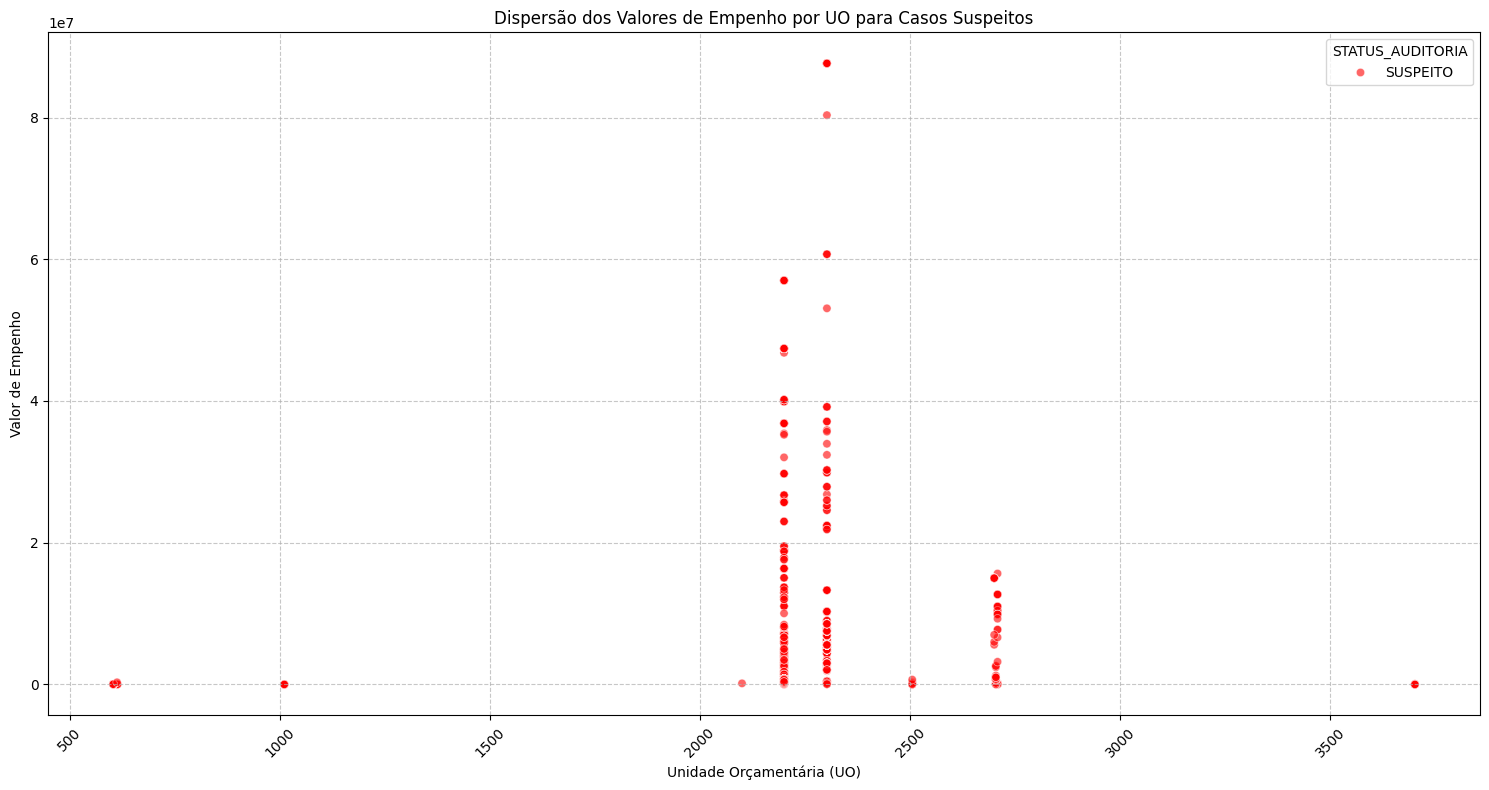

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.scatterplot(data=anomalias, x='UO', y='VALOR_EMPENHO', hue='STATUS_AUDITORIA', palette={'SUSPEITO': 'red'}, alpha=0.6)
plt.title('Dispersão dos Valores de Empenho por UO para Casos Suspeitos')
plt.xlabel('Unidade Orçamentária (UO)')
plt.ylabel('Valor de Empenho')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
top_10_anomalias = anomalias.nlargest(10, 'VALOR_EMPENHO')
display(top_10_anomalias)

,UO,NOME_UO,NOME_CREDOR,NUMERO_EMPENHO,VALOR_EMPENHO,DATA_EMPENHO,NOME_ELEMENTO_DESPESA,JUSTIFICATIVA_SUCINTA,NUMERO_ORDEM_PAGAMENTO,VALOR_ORDEM_PAGAMENTO,DATA_ORDEM_PAGAMENTO,STATUS_AUDITORIA
655674,2302,FUNDO MUNICIPAL DE SAÚDE,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS,671,87636638.28,01/30/2025 00:00:00,OUTROS SERVIÇOS DE TERCEIROS - PESSOA JURÍDICA,DESPESA REFERENTE AO TERMO DE AUTOCOMPOSIÇÃO N...,8614.0,7303053.19,02/03/2025 00:00:00,SUSPEITO
655675,2302,FUNDO MUNICIPAL DE SAÚDE,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS,671,87636638.28,01/30/2025 00:00:00,OUTROS SERVIÇOS DE TERCEIROS - PESSOA JURÍDICA,DESPESA REFERENTE AO TERMO DE AUTOCOMPOSIÇÃO N...,17047.0,7303053.19,02/28/2025 00:00:00,SUSPEITO
655796,2302,FUNDO MUNICIPAL DE SAÚDE,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS,671,87636638.28,01/30/2025 00:00:00,OUTROS SERVIÇOS DE TERCEIROS - PESSOA JURÍDICA,DESPESA REFERENTE AO TERMO DE AUTOCOMPOSIÇÃO N...,25759.0,7303053.19,03/31/2025 00:00:00,SUSPEITO
655797,2302,FUNDO MUNICIPAL DE SAÚDE,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS,671,87636638.28,01/30/2025 00:00:00,OUTROS SERVIÇOS DE TERCEIROS - PESSOA JURÍDICA,DESPESA REFERENTE AO TERMO DE AUTOCOMPOSIÇÃO N...,35080.0,7303053.19,04/30/2025 00:00:00,SUSPEITO
655798,2302,FUNDO MUNICIPAL DE SAÚDE,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS,671,87636638.28,01/30/2025 00:00:00,OUTROS SERVIÇOS DE TERCEIROS - PESSOA JURÍDICA,DESPESA REFERENTE AO TERMO DE AUTOCOMPOSIÇÃO N...,44201.0,7303053.19,05/30/2025 00:00:00,SUSPEITO
655799,2302,FUNDO MUNICIPAL DE SAÚDE,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS,671,87636638.28,01/30/2025 00:00:00,OUTROS SERVIÇOS DE TERCEIROS - PESSOA JURÍDICA,DESPESA REFERENTE AO TERMO DE AUTOCOMPOSIÇÃO N...,52642.0,7303053.19,06/30/2025 00:00:00,SUSPEITO
655800,2302,FUNDO MUNICIPAL DE SAÚDE,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS,671,87636638.28,01/30/2025 00:00:00,OUTROS SERVIÇOS DE TERCEIROS - PESSOA JURÍDICA,DESPESA REFERENTE AO TERMO DE AUTOCOMPOSIÇÃO N...,62273.0,7303053.19,07/31/2025 00:00:00,SUSPEITO
656052,2302,FUNDO MUNICIPAL DE SAÚDE,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS,671,87636638.28,01/30/2025 00:00:00,OUTROS SERVIÇOS DE TERCEIROS - PESSOA JURÍDICA,DESPESA REFERENTE AO TERMO DE AUTOCOMPOSIÇÃO N...,71800.0,7303053.19,08/29/2025 00:00:00,SUSPEITO
656053,2302,FUNDO MUNICIPAL DE SAÚDE,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS,671,87636638.28,01/30/2025 00:00:00,OUTROS SERVIÇOS DE TERCEIROS - PESSOA JURÍDICA,DESPESA REFERENTE AO TERMO DE AUTOCOMPOSIÇÃO N...,80756.0,7303053.19,09/30/2025 00:00:00,SUSPEITO
656054,2302,FUNDO MUNICIPAL DE SAÚDE,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS,671,87636638.28,01/30/2025 00:00:00,OUTROS SERVIÇOS DE TERCEIROS - PESSOA JURÍDICA,DESPESA REFERENTE AO TERMO DE AUTOCOMPOSIÇÃO N...,90474.0,7303053.19,10/31/2025 00:00:00,SUSPEITO


In [ ]:
frequencia_credor = anomalias['NOME_CREDOR'].value_counts()
print("Frequência de NOME_CREDOR nas anomalias:")
display(frequencia_credor.head(10)) # Exibindo os 10 credores mais frequentes

Frequência de NOME_CREDOR nas anomalias:


,count
NOME_CREDOR,
MGS MINAS GERAIS ADMINISTRACAO E SERVICOS SA,2495
ARTEBRILHO MULTSERVICOS LTDA,409
BRINK MOBIL EQUIPAMENTOS EDUCACIONAIS LTDA,354
SUPERGASBRAS ENERGIA LTDA,303
FUNDACAO GUIMARAES ROSA,301
REVENDEDORA DE GAS E PRESTADORA DE SERVICOS IRMAOS ENES LTDA,142
NGC DISTRIBUIDORA DE GAS LTDA,128
AACP SERVICO AMBIENTAL LTDA,109
PORT DISTRIBUIDORA DE INFORMATICA E PAPELARIA LTDA,99


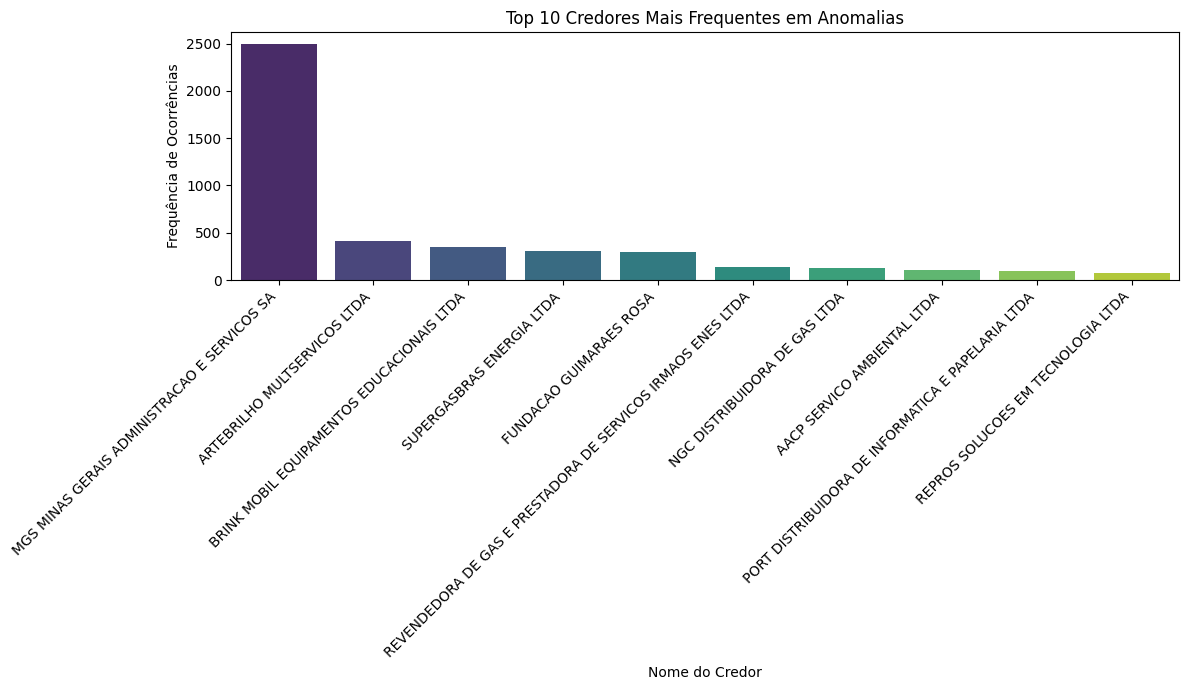

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=frequencia_credor.head(10).index, y=frequencia_credor.head(10).values, hue=frequencia_credor.head(10).index, palette='viridis', legend=False)
plt.title('Top 10 Credores Mais Frequentes em Anomalias')
plt.xlabel('Nome do Credor')
plt.ylabel('Frequência de Ocorrências')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análise Histórica de Valores de Empenho e Ordem de Pagamento para UOs e Credores Anômalos

In [ ]:
# 1. Identificar combinações únicas de UO e NOME_CREDOR das anomalias

unique_anomalous_entities = anomalias[['UO', 'NOME_UO', 'NOME_CREDOR']].drop_duplicates()

# 2. Juntar com o DataFrame original para obter todos os registros históricos dessas entidades
historical_data_for_anomalies = pd.merge(
    df,
    unique_anomalous_entities,
    on=['UO', 'NOME_UO', 'NOME_CREDOR'],
    how='inner'
)

# 3. Calcular a média histórica de VALOR_EMPENHO e VALOR_ORDEM_PAGAMENTO por UO e NOME_CREDOR
historical_averages = historical_data_for_anomalies.groupby(['UO', 'NOME_UO', 'NOME_CREDOR']).agg(
    media_historica_VALOR_EMPENHO=('VALOR_EMPENHO', 'mean'),
    media_historica_VALOR_ORDEM_PAGAMENTO=('VALOR_ORDEM_PAGAMENTO', 'mean')
).reset_index()

print("Médias históricas calculadas com sucesso!")
display(historical_averages.head())

Médias históricas calculadas com sucesso!


,UO,NOME_UO,NOME_CREDOR,media_historica_VALOR_EMPENHO,media_historica_VALOR_ORDEM_PAGAMENTO
0,604,EMPRESA DE INFORMÁTICA E INFORMAÇÃO DO MUNICÍP...,BRISK SOLUCOES AGEIS LTDA,24558.000909,8564.509091
1,613,FUNDO FINANCEIRO,IPREMB INSTITUTO DE PREVIDENCIA SOCIAL DO MU...,15605.581395,7009.805581
2,614,FUNDO PREVIDENCIÁRIO - BHPREV,INSTITUTO TOTUM DE DESENVOLVIMENTO E GESTAO EM...,9495.000000,3745.000000
3,1011,FUNDO MUNICIPAL DE ASSISTÊNCIA SOCIAL,BARBARA CAROLINA PAULINO NEVES,300.000000,300.000000
4,1011,FUNDO MUNICIPAL DE ASSISTÊNCIA SOCIAL,GABRIELA FERREIRA SANTOS,300.000000,300.000000


In [ ]:
# 4. Exportar para CSV
output_filename = 'historico_medio_anomalias.csv'
historical_averages.to_csv(output_filename, index=False, sep=';', encoding='utf8')
print(f"Arquivo '{output_filename}' gerado com sucesso!")

Arquivo 'historico_medio_anomalias.csv' gerado com sucesso!


In [ ]:
# 5. Mover para o Google Drive
import shutil

drive_destination_path = f'/content/drive/My Drive/{output_filename}'

try:
    shutil.move(output_filename, drive_destination_path)
    print(f"Arquivo '{output_filename}' movido com sucesso para '{drive_destination_path}'")
except FileNotFoundError:
    print(f"Erro: O arquivo '{output_filename}' não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro ao mover o arquivo: {e}")

Arquivo 'historico_medio_anomalias.csv' movido com sucesso para '/content/drive/My Drive/historico_medio_anomalias.csv'


### Identificando UOs com maior desvio absoluto em relação à média histórica

In [ ]:
# 1. Mesclar 'anomalias' com 'historical_averages'
anomalias_com_medias = pd.merge(
    anomalias,
    historical_averages,
    on=['UO', 'NOME_UO', 'NOME_CREDOR'],
    how='left'
)

# 2. Calcular o desvio absoluto do VALOR_EMPENHO em relação à média histórica
anomalias_com_medias['DESVIO_ABSOLUTO_EMPENHO'] = abs(anomalias_com_medias['VALOR_EMPENHO'] - anomalias_com_medias['media_historica_VALOR_EMPENHO'])

# 3. Encontrar a UO com o maior desvio absoluto
uo_maior_desvio = anomalias_com_medias.loc[anomalias_com_medias['DESVIO_ABSOLUTO_EMPENHO'].idxmax()]

print("UO com o maior desvio absoluto em VALOR_EMPENHO em relação à média histórica:")
display(uo_maior_desvio[['UO', 'NOME_UO', 'NOME_CREDOR', 'VALOR_EMPENHO', 'media_historica_VALOR_EMPENHO', 'DESVIO_ABSOLUTO_EMPENHO']])

# Top 10 UOs com os maiores desvios absolutos (considerando a anomalia individual com maior desvio para cada UO)
top_10_uos_desvio = anomalias_com_medias.sort_values(by='DESVIO_ABSOLUTO_EMPENHO', ascending=False).drop_duplicates(subset=['UO', 'NOME_UO']).head(10)

print("\nTop 10 UOs com os maiores desvios absolutos (com base na maior anomalia de cada UO):")
display(top_10_uos_desvio[['UO', 'NOME_UO', 'NOME_CREDOR', 'VALOR_EMPENHO', 'media_historica_VALOR_EMPENHO', 'DESVIO_ABSOLUTO_EMPENHO']])

UO com o maior desvio absoluto em VALOR_EMPENHO em relação à média histórica:


,27169
UO,2302
NOME_UO,FUNDO MUNICIPAL DE SAÚDE
NOME_CREDOR,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS
VALOR_EMPENHO,87636638.28
media_historica_VALOR_EMPENHO,2371057.212276
DESVIO_ABSOLUTO_EMPENHO,85265581.067724



Top 10 UOs com os maiores desvios absolutos (com base na maior anomalia de cada UO):


,UO,NOME_UO,NOME_CREDOR,VALOR_EMPENHO,media_historica_VALOR_EMPENHO,DESVIO_ABSOLUTO_EMPENHO
27169,2302,FUNDO MUNICIPAL DE SAÚDE,FUNDACAO HOSPITALAR DO ESTADO DE MINAS GERAIS,87636638.28,2.371057e+06,8.526558e+07
20835,2200,SECRETARIA MUNICIPAL DE EDUCAÇÃO,MGS MINAS GERAIS ADMINISTRACAO E SERVICOS SA,57000000.00,2.105408e+06,5.489459e+07
27002,2700,SECRETARIA MUNICIPAL DE OBRAS E INFRAESTRUTURA,CEMIG DISTRIBUICAO S.A,15000000.00,2.525893e+06,1.247411e+07
35539,2708,SUPERINTENDÊNCIA DE LIMPEZA URBANA,LOCALIX SERVICOS AMBIENTAIS S.A.,12699305.32,1.670979e+06,1.102833e+07
29473,2704,FUNDO MUNICIPAL DE HABITAÇÃO POPULAR,FUNDO DE ARRENDAMENTO RESIDENCIAL FAR,2625000.00,1.100564e+06,1.524436e+06
26769,3701,FUNDO MUNICIPAL DE ASSISTÊNCIA SOCIAL,INSTITUTO DE PROMOCAO SOCIAL E HUMANA DARCY RI...,71648.91,7.163553e+05,6.447063e+05
26884,2505,FUNDAÇÃO DE PARQUES MUNICIPAIS E ZOOBOTÂNICA,ADSERVI ADMINISTRADORA DE SERVICOS LTDA,678922.00,2.576715e+05,4.212505e+05
27949,613,FUNDO FINANCEIRO,IPREMB INSTITUTO DE PREVIDENCIA SOCIAL DO MU...,300000.00,1.560558e+04,2.843944e+05
12278,2100,SECRETARIA MUNICIPAL DE SEGURANÇA E PREVENÇÃO,INSTITUTO DE ESTUDOS DE DESENVOLVIMENTO SUSTEN...,153000.00,9.488545e+04,5.811455e+04
19970,604,EMPRESA DE INFORMÁTICA E INFORMAÇÃO DO MUNICÍP...,BRISK SOLUCOES AGEIS LTDA,897.90,2.455800e+04,2.366010e+04
